In [ ]:
import sys
import os
sys.path.append(os.path.abspath('../utils'))
import pydeck as pdk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data_aggregation_tools import merge_tickets_locations

# Display all columns for dataframes
pd.set_option('display.max_columns', None)

df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")
df_locations = pd.read_csv("../../data/V_SPACE_BUILDING_DETAIL.csv")

# Generate merged tickets / assets file
df_tickets_locations = merge_tickets_locations(df_tickets=df_tickets, df_locations=df_locations, verbose=True)

print(f"shape of df_tickets: {df_tickets.shape}")
print(f"shape of df_locations: {df_locations.shape}")
print(f"shape of df_tickets_locations: {df_tickets_locations.shape}")


/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_33880/662530284.py:12: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")


Original tickets: 227554 rows
Original locations: 105 rows
Merged result: 219372 rows
shape of df_tickets: (227554, 47)
shape of df_locations: (105, 11)
shape of df_tickets_locations: (219372, 58)


In [40]:
df_tickets_locations = df_tickets_locations[['FEP_BUILDING_X_COORDINATE', 'FEP_BUILDING_Y_COORDINATE', 'FEP_BUILDING_DESC', 'FEP_BUILDING_CLASS']]
df_tickets_locations = df_tickets_locations.groupby(['FEP_BUILDING_Y_COORDINATE', 'FEP_BUILDING_X_COORDINATE',  'FEP_BUILDING_DESC', 'FEP_BUILDING_CLASS']).size().reset_index(name='COUNT')


## -------- VISUALIZATION OF GROUPS TEST --------

# import matplotlib.pyplot as plt
# import pandas as pd

# # Create a scatter plot with marker size based on COUNT
# fig, ax = plt.subplots(figsize=(12, 8))

# scatter = ax.scatter(
#     df_tickets_locations['FEP_BUILDING_X_COORDINATE'],
#     df_tickets_locations['FEP_BUILDING_Y_COORDINATE'],
#     s=df_tickets_locations['COUNT'] * 50,  # Scale the count to marker size
#     alpha=0.6,
#     c=df_tickets_locations['COUNT'],
#     cmap='viridis',
#     edgecolors='black',
#     linewidth=0.5
# )

# ax.set_xlabel('X Coordinate')
# ax.set_ylabel('Y Coordinate')
# ax.set_title('Building Locations by Number of Tickets')

# # Add colorbar to show COUNT values
# cbar = plt.colorbar(scatter, ax=ax)
# cbar.set_label('Number of Tickets (COUNT)')

# plt.tight_layout()
# plt.show()

colors = {0: [0, 0, 255], 1: [0, 255, 0], 2: [255, 255, 0], 3: [255, 127, 0], 4: [255, 0, 0]}

df_tickets_locations['COLOR'] = pd.cut(df_tickets_locations['COUNT'], bins=5, labels=False)
df_tickets_locations['COLOR'] = df_tickets_locations['COLOR'].map(colors)

df_tickets_locations.head()


,FEP_BUILDING_Y_COORDINATE,FEP_BUILDING_X_COORDINATE,FEP_BUILDING_DESC,FEP_BUILDING_CLASS,COUNT,COLOR
0,-95.443261,29.658172,Primary Data Center,Administrative,258,"[0, 0, 255]"
1,-95.443232,29.656995,Library Service Center,Academic,786,"[0, 0, 255]"
2,-95.418053,29.722010,IBC Building - 5615 Kirby Drive,Academic,16,"[0, 0, 255]"
3,-95.415897,29.714418,Rice Village Apartments,Residence Hall,786,"[0, 0, 255]"
4,-95.414378,29.716480,Rice Childrens Campus,Support,344,"[0, 0, 255]"


In [41]:
records = df_tickets_locations.to_dict('records')

In [42]:
# layer = pdk.Layer(
#     'HexagonLayer',
#     data=records,
#     get_position=['FEP_BUILDING_Y_COORDINATE', 'FEP_BUILDING_X_COORDINATE'],
#     auto_highlight=True,
#     elevation_scale=30,
#     pickable=True,
#     elevation_range=[0, 10],
#     extruded=True,
#     coverage=10,
#     radius=1)

#pydeck layer initialization
layer = pdk.Layer(
  'ColumnLayer',
  data=records,
  diskResolution= 12,
  extruded=True,
  radius=10,
  #dynamic elevations for ticket filters
  elevationScale= 500 / df_tickets_locations['COUNT'].max(),
  get_position=['FEP_BUILDING_Y_COORDINATE', 'FEP_BUILDING_X_COORDINATE'],
  get_fill_color='COLOR',
  getElevation = 'COUNT',
  pickable=True
)

#set map location
view_state = pdk.ViewState(
    longitude=-95.404182,
    latitude=29.717154,
    zoom=14.7,
    min_zoom=14,
    max_zoom=20,
    pitch=45)

# Combined all of it and render a viewport
r = pdk.Deck(layers=[layer], initial_view_state=view_state, tooltip={"text": "Building: {FEP_BUILDING_DESC}\n Type: {FEP_BUILDING_CLASS}\n Tickets: {COUNT} "})
r.to_html("my_pydeck_map.html", open_browser=True)



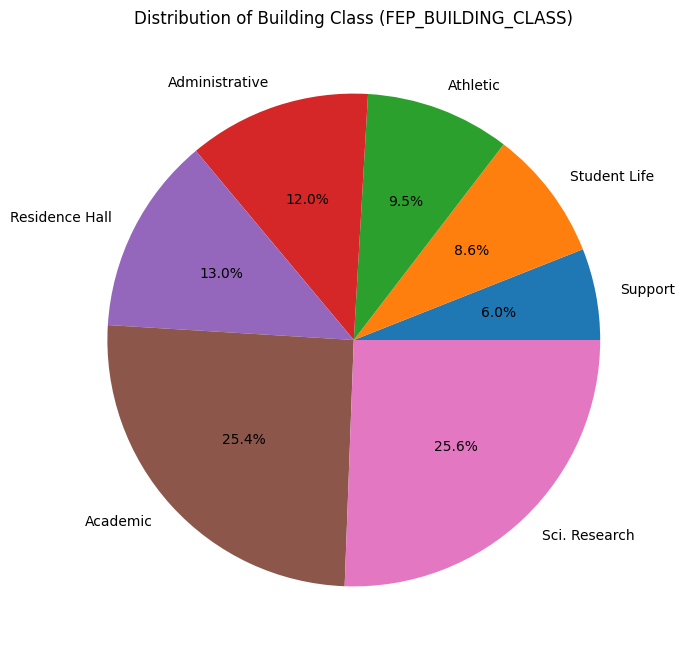

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

class_counts = df_tickets_locations['FEP_BUILDING_CLASS'].value_counts().sort_values()

class_counts.shape

plt.figure(figsize=(10, 8))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Building Class (FEP_BUILDING_CLASS)')
plt.show()